<a href="https://colab.research.google.com/github/Taiphong2006/Cnn-Transformer/blob/final/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# CÀI ĐẶT THƯ VIỆN (Chạy tự động ngầm)
# ==========================================
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas

# ==========================================
# IMPORT VÀ KHAI BÁO
# ==========================================
import pandas as pd
import numpy as np
import evaluate
import os
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Lựa chọn mô hình tối ưu nhất cho dữ liệu mạng xã hội có chứa "@user"
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
NUM_LABELS = 3

# Đường dẫn tới file dataset (Sửa lại nếu file của bạn nằm trong thư mục 'sentiment/')
train_path = "train.csv"
val_path = "validation.csv"
test_path = "test.csv"
# ==========================================
# BƯỚC 1: TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU CHỐNG LỖI NaN
# ==========================================
def clean_and_save_data(input_file, output_file):
    # Đọc file CSV
    df = pd.read_csv(input_file)

    # 1. Xóa các dòng có giá trị rỗng ở cột text hoặc label
    df = df.dropna(subset=['text', 'label'])

    # 2. Ép kiểu bắt buộc cột label về dạng số nguyên (integer) để PyTorch tính Loss chính xác
    df['label'] = df['label'].astype(int)

    # Lưu ra file tạm để Hugging Face Dataset đọc vào
    df.to_csv(output_file, index=False)
    print(f"Đã làm sạch và lưu: {output_file} (Tổng số dòng: {len(df)})")

# Thực thi làm sạch
clean_and_save_data(train_path, "train_clean.csv")
clean_and_save_data(val_path, "val_clean.csv")
clean_and_save_data(test_path, "test_clean.csv")

# ==========================================
# BƯỚC 2: TẢI DATASET & TOKENIZATION
# ==========================================
dataset = load_dataset("csv", data_files={
    "train": "train_clean.csv",
    "validation": "val_clean.csv",
    "test": "test_clean.csv"
})
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    # Cắt văn bản ở 256 tokens để tiết kiệm RAM trên Colab
    return tokenizer(examples["text"], truncation=True, max_length=256)

tokenized_datasets = dataset.map(preprocess_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================================
# BƯỚC 3: KHỞI TẠO MÔ HÌNH & METRICS ĐÁNH GIÁ
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True # Bỏ qua lỗi kích thước lớp cuối nếu số nhãn thay đổi
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}
# ==========================================
# BƯỚC 4: HUẤN LUYỆN (FINE-TUNING)
# ==========================================
training_args = TrainingArguments(
    output_dir="./twitter-sentiment-model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",              # Đã dùng cú pháp chuẩn mới
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=False,                         # QUAN TRỌNG: TẮT fp16 ĐỂ KHẮC PHỤC TRIỆT ĐỂ LỖI NaN LOSS TRÊN COLAB
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,         # Đã dùng cú pháp chuẩn mới thay cho 'tokenizer'
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print("\n🚀 BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN...")
trainer.train()

# ==========================================
# BƯỚC 5: ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
print("\n📊 ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP DỮ LIỆU TEST...")
test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])
print(test_results)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
Đã làm sạch và lưu: train_clean.csv (Tổng số dòng: 38914)
Đã làm sạch và lưu: val_clean.csv (Tổng số dòng: 8980)
Đã làm sạch và lưu: test_clean.csv (Tổng số dòng: 11975)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


📊 ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP DỮ LIỆU TEST...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.296151,0.578420,3,0.765595,0.760649


{'eval_loss': 0.5784202814102173, 'eval_accuracy': 0.7655949895615867, 'eval_f1_macro': 0.7606492176089231}


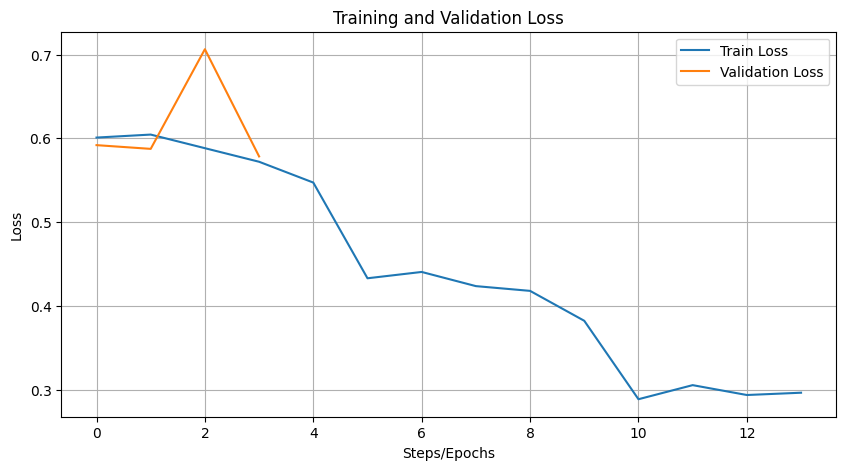


--- Đang tạo Ma trận nhầm lẫn ---


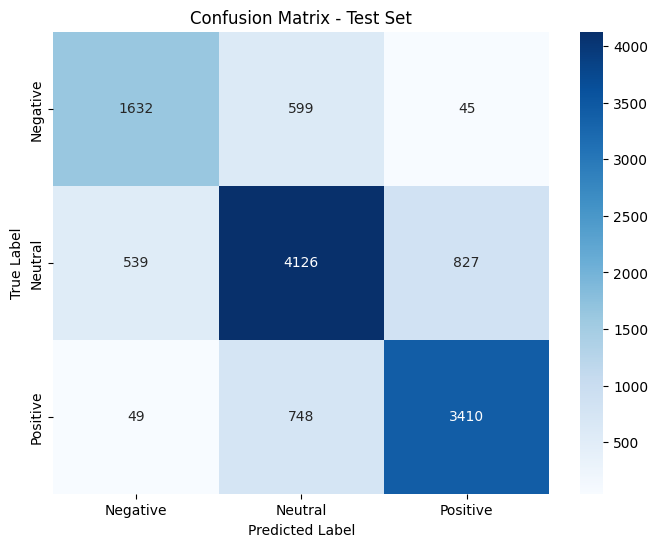

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Vẽ biểu đồ Loss
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Steps/Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. Tạo Ma trận nhầm lẫn (Confusion Matrix) trên tập Test
print("\n--- Đang tạo Ma trận nhầm lẫn ---")
predictions = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
labels = ['Negative', 'Neutral', 'Positive'] # Thứ tự nhãn phổ biến

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()